Total Parameter Combinations: 446
Total Iterations (Parameter Combinations x CV Folds): 4460
Starting Grid Search...
Fitting 10 folds for each of 446 candidates, totalling 4460 fits


/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Grid Search Completed.

Best Average AUC: 0.6739 ± 0.0469
Average Accuracy: 0.6657 ± 0.0219
Average Precision: 0.1552 ± 0.0202
Average F1 Score: 0.2463 ± 0.0315

Best Hyperparameters:
  lr__C: 30
  lr__l1_ratio: None
  lr__penalty: l2
  lr__solver: sag
  resampler: RandomOverSampler()
  resampler__sampling_strategy: auto

Generating cross-validated predicted probabilities...
Optimizing threshold to maximize F1 score...

Calculating metrics at the optimal threshold across folds...
  Fold 1: F1=0.2775, Accuracy=0.7981, Precision=0.2069
  Fold 2: F1=0.2667, Accuracy=0.8220, Precision=0.2128
  Fold 3: F1=0.2395, Accuracy=0.7945, Precision=0.1802
  Fold 4: F1=0.2597, Accuracy=0.8155, Precision=0.2041
  Fold 5: F1=0.2282, Accuracy=0.8139, Precision=0.1828
  Fold 6: F1=0.2236, Accuracy=0.7977, Precision=0.1714
  Fold 7: F1=0.3733, Accuracy=0.8479, Precision=0.2979
  Fold 8: F1=0.3165, Accuracy=0.8463, Precision=0.2683
  Fold 9: F1=0.2073, Accuracy=0.7896, Precision=0.1589
  Fold 10: F1=0.3407

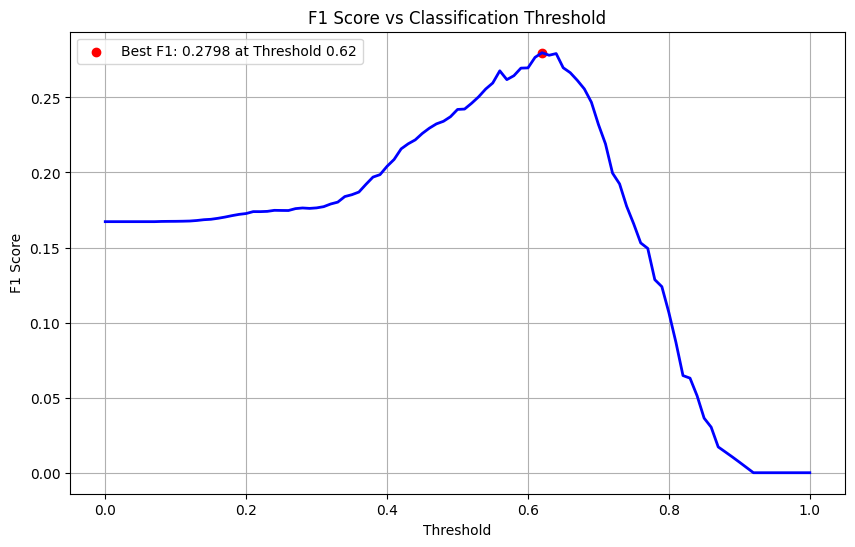

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, f1_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
import matplotlib.pyplot as plt
import warnings
from math import prod

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load the dataset
# Replace the file path with your actual path
data = pd.read_excel("class1_dataset.xlsx")

# Extract the predictors and outcome
X = data.drop('RRI', axis=1)
Y = data['RRI']

# Define the feature indexes to be used as predictors
# Note: Pandas uses 0-based indexing
feature_indexes = [24, 38, 20, 16, 15, 12, 3, 10, 13, 21, 9, 22, 26, 33, 19, 2, 35, 32, 28, 6, 30]

# Select the specified features using .iloc
X_selected = X.iloc[:, feature_indexes]

# Initialize the Logistic Regression Classifier
lr = LogisticRegression(random_state=42, max_iter=10000)

# Initialize the resampling strategies
resamplers = [
    ('smote', SMOTE()),
    ('adasyn', ADASYN()),
    ('random_oversampler', RandomOverSampler())
]

# Create a Pipeline with Resampler and Logistic Regression
pipeline = ImbPipeline([
    ('resampler', SMOTE()),  # Placeholder, will be set in GridSearchCV
    ('lr', lr)
])

# Define the parameter grid for hyperparameter tuning
param_grid = [
    # Logistic Regression with L1 penalty and actual resamplers
    {
        'resampler': [SMOTE(), ADASYN(), RandomOverSampler()],
        'resampler__sampling_strategy': ['auto', 0.2, 0.5, 1.5],
        'lr__penalty': ['l1'],
        'lr__C': [5, 10.0, 20, 30, 50],
        'lr__solver': ['saga'],
        # 'lr__l1_ratio' is not used for 'l1' penalty; set to None
        'lr__l1_ratio': [None]
    },
    # Logistic Regression with L1 penalty and passthrough
    {
        'resampler': ['passthrough'],
        # Exclude 'resampler__sampling_strategy' when passthrough is used
        'lr__penalty': ['l1'],
        'lr__C': [5, 10.0, 20, 30, 50],
        'lr__solver': ['saga'],
        'lr__l1_ratio': [None]
    },
    # Logistic Regression with L2 penalty and actual resamplers
    {
        'resampler': [SMOTE(), ADASYN(), RandomOverSampler()],
        'resampler__sampling_strategy': ['auto', 0.2, 0.5, 1.5],
        'lr__penalty': ['l2'],
        'lr__C': [5, 10.0, 20, 30, 50],
        'lr__solver': ['lbfgs', 'sag', 'saga'],
        'lr__l1_ratio': [None]
    },
    # Logistic Regression with L2 penalty and passthrough
    {
        'resampler': ['passthrough'],
        'lr__penalty': ['l2'],
        'lr__C': [5, 10.0, 20, 30, 500],
        'lr__solver': ['lbfgs', 'sag', 'saga'],
        'lr__l1_ratio': [None]
    },
    # Logistic Regression with ElasticNet penalty and actual resamplers
    {
        'resampler': [SMOTE(), ADASYN(), RandomOverSampler()],
        'resampler__sampling_strategy': ['auto', 0.2, 0.5, 1.5],
        'lr__penalty': ['elasticnet'],
        'lr__C': [5, 10.0, 20, 30, 50],
        'lr__solver': ['saga'],
        'lr__l1_ratio': [0.1, 0.3, 0.5]  # Only relevant for 'elasticnet'
    },
    # Logistic Regression with ElasticNet penalty and passthrough
    {
        'resampler': ['passthrough'],
        'lr__penalty': ['elasticnet'],
        'lr__C': [1.0, 10.0],
        'lr__solver': ['saga'],
        'lr__l1_ratio': [0.1, 0.3, 0.5]
    }
]


# Define the scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'f1': 'f1'
}

# Define the Stratified 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Calculate the total number of parameter combinations
n_param_combinations = sum([prod([len(v) for v in param_dict.values() if v is not None]) for param_dict in param_grid])

# Calculate the total number of iterations
total_iterations = n_param_combinations * cv.get_n_splits(X_selected, Y)

print(f"Total Parameter Combinations: {n_param_combinations}")
print(f"Total Iterations (Parameter Combinations x CV Folds): {total_iterations}")

# Initialize Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Use 'roc_auc' to select the best model
    cv=cv,
    n_jobs=7,  # Use all available cores
    verbose=1,  # Set to 1 for basic progress messages
    return_train_score=False
)

# Fit the Grid Search to the data without progress bar
print("Starting Grid Search...")
grid_search.fit(X_selected, Y)
print("Grid Search Completed.")

# Retrieve the best average AUC and its standard deviation
best_auc = grid_search.best_score_
# Retrieve the standard deviation from cv_results_
# Identify the index of the best parameter set
best_index = grid_search.best_index_
best_auc_std = grid_search.cv_results_['std_test_roc_auc'][best_index]

# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Retrieve the other metrics for the best parameter set
best_accuracy = grid_search.cv_results_['mean_test_accuracy'][best_index]
best_accuracy_std = grid_search.cv_results_['std_test_accuracy'][best_index]

best_precision = grid_search.cv_results_['mean_test_precision'][best_index]
best_precision_std = grid_search.cv_results_['std_test_precision'][best_index]

best_f1 = grid_search.cv_results_['mean_test_f1'][best_index]
best_f1_std = grid_search.cv_results_['std_test_f1'][best_index]

# Output the results
print(f"\nBest Average AUC: {best_auc:.4f} ± {best_auc_std:.4f}")
print(f"Average Accuracy: {best_accuracy:.4f} ± {best_accuracy_std:.4f}")
print(f"Average Precision: {best_precision:.4f} ± {best_precision_std:.4f}")
print(f"Average F1 Score: {best_f1:.4f} ± {best_f1_std:.4f}")
print("\nBest Hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Retrieve the best estimator from Grid Search
best_estimator = grid_search.best_estimator_

# Use cross_val_predict to get cross-validated predicted probabilities
# LogisticRegression inherently supports predict_proba
print("\nGenerating cross-validated predicted probabilities...")
y_pred_proba = cross_val_predict(best_estimator, X_selected, Y, cv=cv, method='predict_proba', n_jobs=7)[:, 1]

# Define a range of threshold values to evaluate
thresholds = np.linspace(0.0, 1.0, 101)

# Initialize variables to store the best metrics and threshold
best_threshold = 0.5
best_f1_score = 0.0
best_accuracy = 0.0
best_precision = 0.0

print("Optimizing threshold to maximize F1 score...")

for threshold in thresholds:
    # Convert predicted probabilities to binary predictions based on the threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Calculate F1 score
    current_f1 = f1_score(Y, y_pred)
    
    # Update the best metrics and threshold if current F1 is better
    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        best_threshold = threshold
        best_accuracy = accuracy_score(Y, y_pred)
        best_precision = precision_score(Y, y_pred, zero_division=0)

# Calculate standard deviations using cross-validation
# To compute standard deviations, we'll perform cross-validation predictions and calculate metrics at the best threshold

# Initialize lists to store per-fold metrics
f1_scores = []
accuracies = []
precisions = []

print("\nCalculating metrics at the optimal threshold across folds...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_selected, Y), 1):
    # Split data
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
    # Fit the model on the training data
    best_estimator.fit(X_train, y_train)
    
    # Predict probabilities on the test data
    y_proba_fold = best_estimator.predict_proba(X_test)[:, 1]
    
    # Apply the optimal threshold
    y_pred_fold = (y_proba_fold >= best_threshold).astype(int)
    
    # Calculate metrics
    fold_f1 = f1_score(y_test, y_pred_fold)
    fold_accuracy = accuracy_score(y_test, y_pred_fold)
    fold_precision = precision_score(y_test, y_pred_fold, zero_division=0)
    
    # Append to lists
    f1_scores.append(fold_f1)
    accuracies.append(fold_accuracy)
    precisions.append(fold_precision)
    
    print(f"  Fold {fold}: F1={fold_f1:.4f}, Accuracy={fold_accuracy:.4f}, Precision={fold_precision:.4f}")

# Calculate mean and standard deviation for the metrics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

mean_precision = np.mean(precisions)
std_precision = np.std(precisions)

# Output the optimized threshold and corresponding metrics
print(f"\n=== Optimized Threshold ===")
print(f"Threshold for Maximum F1 Score: {best_threshold:.2f}")

print(f"\n=== Metrics at Optimal Threshold ===")
print(f"F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")

# Plot F1 Score vs Threshold
f1_scores_plot = []
for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(Y, y_pred)
    f1_scores_plot.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_plot, color='blue', lw=2)
plt.scatter(best_threshold, best_f1_score, color='red', 
            label=f'Best F1: {best_f1_score:.4f} at Threshold {best_threshold:.2f}')
plt.title('F1 Score vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()


=== Feature Coefficients (Descending Order) ===
                  Feature  Coefficient
   tracking_period_injury     2.618926
    class1_SNP_risk_score     1.360031
      past_month_distance     1.204346
        Q_angle_asymmetry     0.839222
           navicular_drop     0.707992
 knee_flexion_peak_torque     0.658180
         past_month_ratio     0.480944
                 rs591058     0.334506
                rs4986938    -0.176714
                rs1800795    -0.274394
                rs4789932    -0.277614
                BMD_spine    -0.347275
hip_abduction_peak_torque    -0.456419
                rs9340799    -0.477965
                rs1144393    -0.549924
    lower_limb_days_total    -0.581701
           SC_past_season    -0.620537
                  Q_angle    -0.729596
           Impact_peak_12    -0.757071
        average_run_hours    -0.959838
           Duty_factor_12    -1.280184


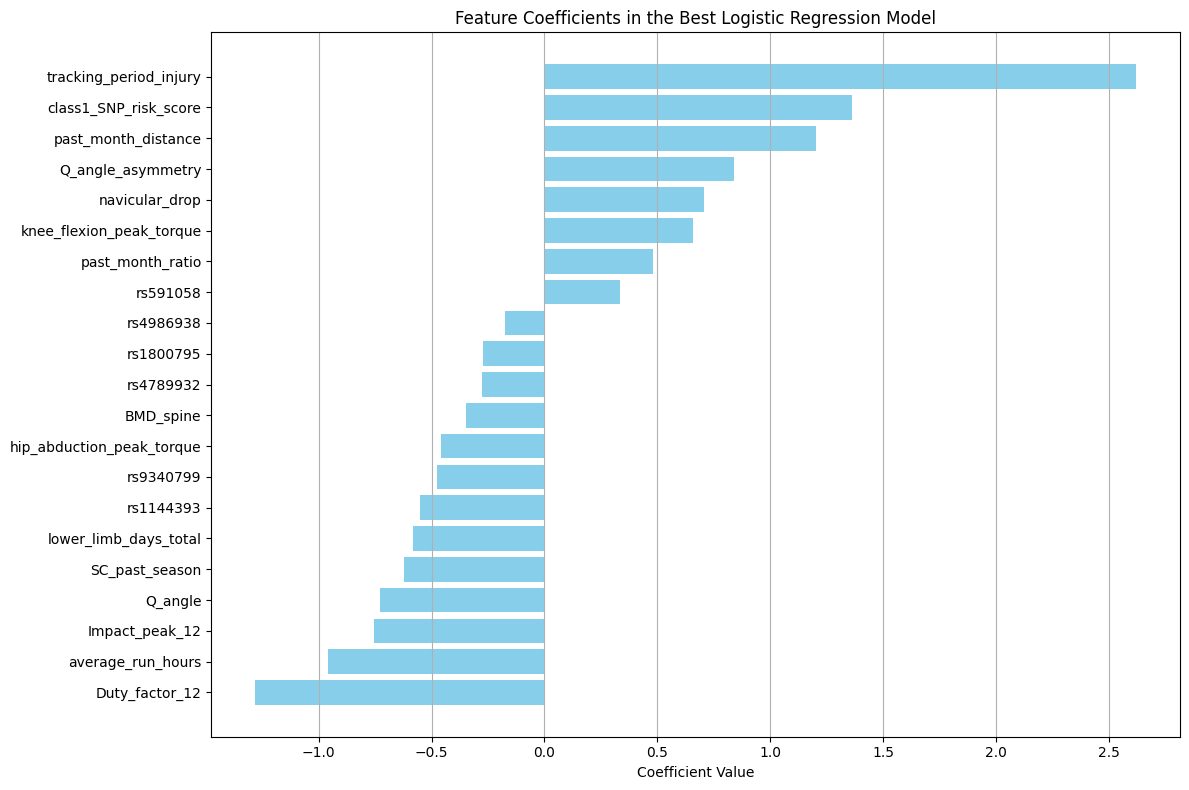

/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [4]:
# ================================================
# Analyze and Display Feature Coefficients
# ================================================

# Ensure that the best_estimator has a named 'lr' step
if 'lr' not in best_estimator.named_steps:
    raise ValueError("The pipeline does not contain a 'lr' step for Logistic Regression.")

# Extract the Logistic Regression model from the pipeline
logistic_model = best_estimator.named_steps['lr']

# Get the feature names from the selected features
feature_names = X_selected.columns

# Extract the coefficients
# For binary classification, coef_ is of shape (1, n_features)
coefficients = logistic_model.coef_[0]

# Create a DataFrame mapping feature names to their coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort the DataFrame by coefficient value in descending order
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

# Display the sorted coefficients
print("\n=== Feature Coefficients (Descending Order) ===")
print(coef_df_sorted.to_string(index=False))

# Optional: Plot the coefficients for better visualization
plt.figure(figsize=(12, 8))
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients in the Best Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest coefficients on top
plt.grid(axis='x')
plt.tight_layout()
plt.show()